In [1]:
import tensorflow as tf
import keras
import numpy
import sklearn
import matplotlib

2026-02-24 18:23:36.285838: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 18:23:36.287954: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-24 18:23:36.329635: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-24 18:23:36.513801: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-24 18:23:37.440811: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

In [2]:
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import InputLayer, Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from keras import utils as np_utils
import matplotlib.pyplot as plt

In [3]:
# carregando o dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [4]:
# vendo um exemplo
X_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [5]:
# vendo os formatos dos dados
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [6]:
y_train.shape, y_test.shape

((50000, 1), (10000, 1))

Text(0.5, 1.0, 'Classe [6]')

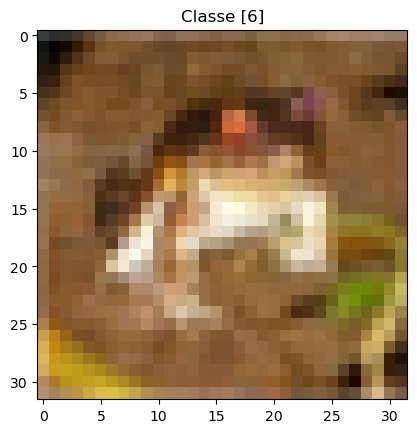

In [7]:
# mostrando a primeira imagem e sua resposta
plt.imshow(X_train[0], cmap='gray')
plt.title('Classe ' + str(y_train[0]))

In [8]:
# convertendo para float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [9]:
# normalizando
X_train /= 255
X_test /= 255

In [10]:
# vendo se deu certo
X_train.max(), X_train.min()

(1.0, 0.0)

In [11]:
# transformando o resultado em valor categórico
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
y_train[0], y_test[0]

(array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
 array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]))

### Irei criar a rede neural de algumas formas diferentes para comparar o desempenho delas

### Rede neural 1

In [12]:
# criando a rede neural
neural_network = Sequential()

# camada de entrada
neural_network.add(InputLayer(shape=(32, 32, 3)))

# Camadas de transformação da imagem
neural_network.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu')) # 32 detectores de caracteristicas de tamanho 3x3
neural_network.add(BatchNormalization()) # normalizar os dados novamente
neural_network.add(MaxPooling2D(pool_size=(2,2))) # Max pooling

# Camadas de transformação da imagem 
neural_network.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu')) # 32 detectores de caracteristicas de tamanho 3x3
neural_network.add(BatchNormalization()) # normalizar os dados novamente
neural_network.add(MaxPooling2D(pool_size=(2,2))) # Max pooling

neural_network.add(Flatten()) # transforma a matriz em uma array

# Parte densa da rede neural
neural_network.add(Dense(units=128, activation='relu')) # camada densa
neural_network.add(Dropout(0.2)) # evita overfitting
neural_network.add(Dense(units=128, activation='relu')) # camada densa
neural_network.add(Dropout(0.2)) # evita overfitting

# camada de saída
neural_network.add(Dense(units=10, activation='softmax')) 

In [13]:
# sumário
neural_network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,786 (686.66 KB)

 Trainable params: 175,658 (686.16 KB)

 Non-trainable params: 128 (512.00 B)

In [14]:
# compilando
neural_network.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# realizando o treinamento
neural_network.fit(X_train, y_train, batch_size=128, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.3503 - loss: 1.8417 - val_accuracy: 0.3982 - val_loss: 1.7230
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.5598 - loss: 1.2351 - val_accuracy: 0.6058 - val_loss: 1.1034
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.6275 - loss: 1.0569 - val_accuracy: 0.6003 - val_loss: 1.1490
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.6757 - loss: 0.9279 - val_accuracy: 0.6397 - val_loss: 1.0212
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.7114 - loss: 0.8290 - val_accuracy: 0.6545 - val_loss: 1.0044
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.7291 - loss: 0.7668 - val_accuracy: 0.6609 - val_loss: 0.9869
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.7531 - loss: 0.6998 - val_accuracy: 0.6939 - val_loss: 0.8789
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.7721 - loss: 0.6495 - 

### Rede Neural 2

In [17]:
# criando a rede neural
neural_network = Sequential()

# camada de entrada
neural_network.add(InputLayer(shape=(32, 32, 3)))

# Camadas de transformação da imagem
neural_network.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu')) # 32 detectores de caracteristicas de tamanho 3x3
neural_network.add(BatchNormalization()) # normalizar os dados novamente
neural_network.add(MaxPooling2D(pool_size=(2,2))) # Max pooling

# Camadas de transformação da imagem 
neural_network.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu')) # 32 detectores de caracteristicas de tamanho 3x3
neural_network.add(BatchNormalization()) # normalizar os dados novamente
neural_network.add(MaxPooling2D(pool_size=(2,2))) # Max pooling

# Camadas de transformação da imagem 
neural_network.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu')) # 32 detectores de caracteristicas de tamanho 3x3
neural_network.add(BatchNormalization()) # normalizar os dados novamente
neural_network.add(MaxPooling2D(pool_size=(2,2))) # Max pooling

neural_network.add(Flatten()) # transforma a matriz em uma array

# Parte densa da rede neural
neural_network.add(Dense(units=128, activation='relu')) # camada densa
neural_network.add(Dropout(0.2)) # evita overfitting
neural_network.add(Dense(units=128, activation='relu')) # camada densa
neural_network.add(Dropout(0.2)) # evita overfitting

# camada de saída
neural_network.add(Dense(units=10, activation='softmax')) 

# compilando
neural_network.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# realizando o treinamento
neural_network.fit(X_train, y_train, batch_size=128, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 104ms/step - accuracy: 0.3815 - loss: 1.7415 - val_accuracy: 0.3081 - val_loss: 2.2313
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 97ms/step - accuracy: 0.6006 - loss: 1.1488 - val_accuracy: 0.5978 - val_loss: 1.1301
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.6669 - loss: 0.9549 - val_accuracy: 0.6283 - val_loss: 1.0670
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.7139 - loss: 0.8262 - val_accuracy: 0.6790 - val_loss: 0.9286
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.7489 - loss: 0.7251 - val_accuracy: 0.5711 - val_loss: 1.4094
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.7729 - loss: 0.6514 - val_accuracy: 0.6342 - val_loss: 1.1129
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.7954 - loss: 0.5927 - val_accuracy: 0.6920 - val_loss: 0.9396
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.8154 - loss: 0.5303 -

### Rede Neural 3

In [19]:
# criando a rede neural
neural_network = Sequential()

# camada de entrada
neural_network.add(InputLayer(shape=(32, 32, 3)))

# Camadas de transformação da imagem
neural_network.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')) # 32 detectores de caracteristicas de tamanho 3x3
neural_network.add(BatchNormalization()) # normalizar os dados novamente
neural_network.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')) # 32 detectores de caracteristicas de tamanho 3x3
neural_network.add(BatchNormalization()) # normalizar os dados novamente
neural_network.add(MaxPooling2D(pool_size=(2,2))) # Max pooling
neural_network.add(Dropout(0.2)) # evita overfitting

neural_network.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')) # 32 detectores de caracteristicas de tamanho 3x3
neural_network.add(BatchNormalization()) # normalizar os dados novamente
neural_network.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')) # 32 detectores de caracteristicas de tamanho 3x3
neural_network.add(BatchNormalization()) # normalizar os dados novamente
neural_network.add(MaxPooling2D(pool_size=(2,2))) # Max pooling
neural_network.add(Dropout(0.3)) # evita overfitting

neural_network.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu')) # 32 detectores de caracteristicas de tamanho 3x3
neural_network.add(BatchNormalization()) # normalizar os dados novamente
neural_network.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu')) # 32 detectores de caracteristicas de tamanho 3x3
neural_network.add(BatchNormalization()) # normalizar os dados novamente
neural_network.add(MaxPooling2D(pool_size=(2,2))) # Max pooling
neural_network.add(Dropout(0.4)) # evita overfitting

neural_network.add(Flatten()) # transforma a matriz em uma array

# Parte densa da rede neural
neural_network.add(Dense(units=128, activation='relu')) # camada densa
neural_network.add(Dropout(0.5)) # evita overfitting
neural_network.add(Dense(units=128, activation='relu')) # camada densa
neural_network.add(Dropout(0.5)) # evita overfitting

# camada de saída
neural_network.add(Dense(units=10, activation='softmax')) 

# compilando
neural_network.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# realizando o treinamento
neural_network.fit(X_train, y_train, batch_size=128, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 121s 298ms/step - accuracy: 0.1630 - loss: 2.3806 - val_accuracy: 0.2146 - val_loss: 2.1367
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 115s 294ms/step - accuracy: 0.3446 - loss: 1.7314 - val_accuracy: 0.5039 - val_loss: 1.4002
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 116s 296ms/step - accuracy: 0.4567 - loss: 1.4593 - val_accuracy: 0.5886 - val_loss: 1.2077
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 116s 296ms/step - accuracy: 0.5490 - loss: 1.2679 - val_accuracy: 0.6555 - val_loss: 1.0731
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 115s 295ms/step - accuracy: 0.6074 - loss: 1.1234 - val_accuracy: 0.6774 - val_loss: 1.0054
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 116s 296ms/step - accuracy: 0.6463 - loss: 1.0376 - val_accuracy: 0.6793 - val_loss: 0.9691
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 116s 297ms/step - accuracy: 0.6752 - loss: 0.9554 - val_accuracy: 0.6920 - val_loss: 0.8992
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 116s 296ms/step - accuracy: 0.7013 -